# Pharmaceutical Warehouse Cost & Inventory Analysis

**Author:** Vivian Nguyen  
**Dataset:** Fresenius Kabi Polska - Real-world pharmaceutical warehouse data (via Kaggle)  
**Tools:** Python (Pandas, NumPy, Matplotlib, Seaborn), Power BI  

---

## Project Overview

This project analyses 3 years of warehouse operations data (2023–2025) for a pharmaceutical company to:

1. **Understand sales trends** across products and time periods
2. **Identify storage cost drivers** — which products are most expensive to hold?
3. **Detect inventory risk** — which products risk stockout or waste from expiry?
4. **Compare actual sales vs financial plan** — where are the biggest variances?
5. **Produce business recommendations** to reduce costs and optimise stock

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

# Load all four files
train  = pd.read_csv('sales_train_2023_2024.csv')
test   = pd.read_csv('sales_test_2025.csv')
params = pd.read_csv('products_parameters.csv')
fplan  = pd.read_csv('financial_plan.csv')

print('Files loaded successfully')
print(f' Train rows : {len(train)}')
print(f' Test rows  : {len(test)}')
print(f' Products   : {len(params)}')
print(f' Fin Plan   : {len(fplan)}')

Files loaded successfully
 Train rows : 500
 Test rows  : 500
 Products   : 250
 Fin Plan   : 250


## 2. Data Exploration & Cleaning

In [2]:
# Preview each file
print('=== TRAIN FILE ===')
print(train.head(3))
print('\nUnique Types:', train['Type'].unique())

print('\n=== PRODUCTS PARAMETERS ===')
print(params.head(3))

print('\n=== FINANCIAL PLAN ===')
print(fplan.head(3))

=== TRAIN FILE ===
  ProductID Product_name             Type  2023-01  2023-02  2023-03  2023-04  \
0      P001  Product 001            Sales       56       47       43       40   
1      P001  Product 001  Inventory_level      219      172      129       89   
2      P002  Product 002            Sales       34       29       34       29   

   2023-05  2023-06  2023-07  ...  2024-03  2024-04  2024-05  2024-06  \
0       50       72       66  ...       44       55       44       61   
1       39      237      171  ...       99       44        0      229   
2       28       32       37  ...       28       33       35       31   

   2024-07  2024-08  2024-09  2024-10  2024-11  2024-12  
0       81       59       46       53       63       47  
1      148       89       43      366      303      256  
2       37       33       32       41       25       29  

[3 rows x 27 columns]

Unique Types: ['Sales' 'Inventory_level']

=== PRODUCTS PARAMETERS ===
  ProductID Product_name  Storage_co

In [3]:
# Separate Sales vs Inventory rows
# The Type column distinguishes sales records from inventory records
train_sales = train[train['Type'].str.lower().str.contains('sale|demand|sold', na=False)].copy()
train_stock = train[train['Type'].str.lower().str.contains('stock|inventory|level', na=False)].copy()

test_sales  = test[test['Type'].str.lower().str.contains('sale|demand|sold', na=False)].copy()
test_stock  = test[test['Type'].str.lower().str.contains('stock|inventory|level', na=False)].copy()

if len(train_sales) == 0:
    print('Could not auto-detect Types. Unique values are:')
    print(train['Type'].value_counts())
else:
    print(f'Sales rows (train): {len(train_sales)}')
    print(f'Stock rows (train): {len(train_stock)}')

Sales rows (train): 250
Stock rows (train): 250


In [4]:
# Reshape from wide to long format
# Each month is currently a column — melt it into rows for analysis

id_cols = ['ProductID', 'Product_name', 'Type']

def melt_wide(df, id_cols):
    month_cols = [c for c in df.columns if c not in id_cols]
    melted = df.melt(id_vars=id_cols, value_vars=month_cols,
                     var_name='Month', value_name='Value')
    melted['Month'] = pd.to_datetime(melted['Month'], format='%Y-%m')
    melted['Value'] = pd.to_numeric(melted['Value'], errors='coerce').fillna(0)
    return melted

train_long = melt_wide(train, id_cols)
test_long  = melt_wide(test,  id_cols)
all_long   = pd.concat([train_long, test_long], ignore_index=True)

# Separate by type using the actual type values in the data
types = all_long['Type'].unique()
print('All Type values found:', types)

# Sales = first type, Stock = second type (adjust if needed after seeing output)
sales_type  = [t for t in types if any(k in t.lower() for k in ['sale','demand','sold'])]
stock_type  = [t for t in types if any(k in t.lower() for k in ['stock','inventory','level'])]

sales_long = all_long[all_long['Type'].isin(sales_type)].copy()
stock_long = all_long[all_long['Type'].isin(stock_type)].copy()

print(f'Total sales records : {len(sales_long)}')
print(f'Total stock records  : {len(stock_long)}')

All Type values found: ['Sales' 'Inventory_level']
Total sales records : 9000
Total stock records  : 9000


In [5]:
# Check for missing values
print('Missing values in params:')
print(params.isnull().sum())
print('\nMissing values in financial plan:')
print(fplan.isnull().sum())

# Fill any missing numeric params with median
for col in ['Storage_cost_PLN_per_unit_month','Shelf_life_months',
            'Lead_time_months','Safety_stock_months','Price_PLN_per_unit']:
    if col in params.columns:
        params[col] = params[col].fillna(params[col].median())

Missing values in params:
ProductID                          0
Product_name                       0
Storage_cost_PLN_per_unit_month    0
Shelf_life_months                  0
Lead_time_months                   0
Safety_stock_months                0
Price_PLN_per_unit                 0
dtype: int64

Missing values in financial plan:
ProductID             0
Product_name          0
Plan_2023_units       0
Plan_2024_units       0
Plan_2025_units       0
Plan_2023_PLN         0
Plan_2024_PLN         0
Plan_2025_PLN         0
Price_PLN_per_unit    0
dtype: int64


## 3. Sales Trend Analysis

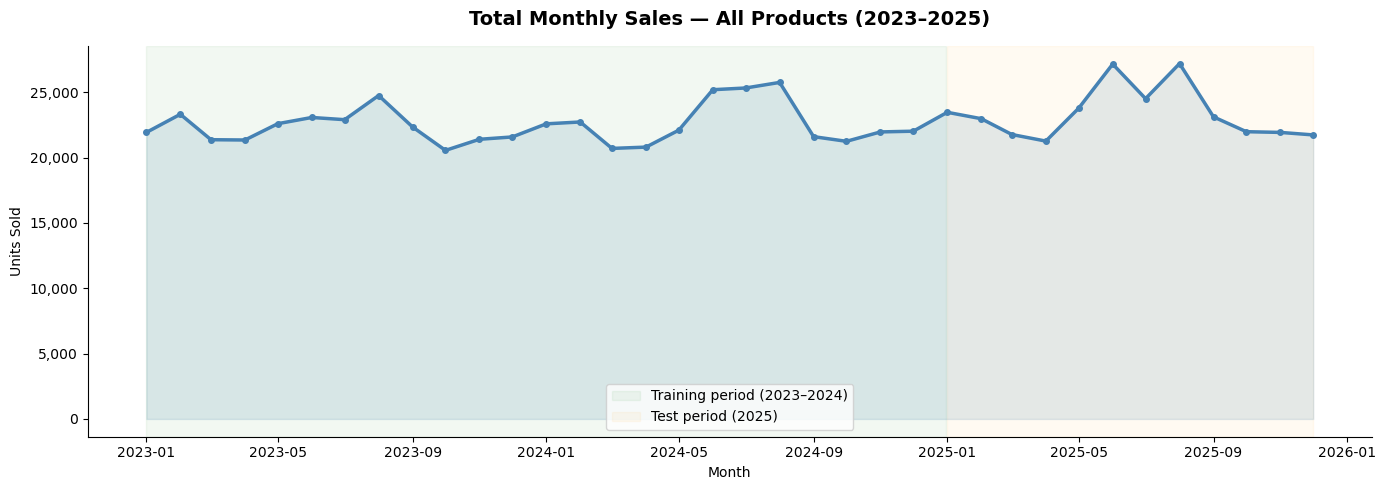

Chart saved: 01_total_monthly_sales.png


In [6]:
# Total monthly sales across all products
monthly_total = sales_long.groupby('Month')['Value'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly_total['Month'], monthly_total['Value'],
                alpha=0.15, color='steelblue')
ax.plot(monthly_total['Month'], monthly_total['Value'],
        color='steelblue', linewidth=2.5, marker='o', markersize=4)

# Shade train vs test period
ax.axvspan(monthly_total['Month'].min(),
           pd.Timestamp('2024-12-31'), alpha=0.05, color='green', label='Training period (2023–2024)')
ax.axvspan(pd.Timestamp('2025-01-01'),
           monthly_total['Month'].max(), alpha=0.05, color='orange', label='Test period (2025)')

ax.set_title('Total Monthly Sales — All Products (2023–2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Units Sold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('01_total_monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 01_total_monthly_sales.png')

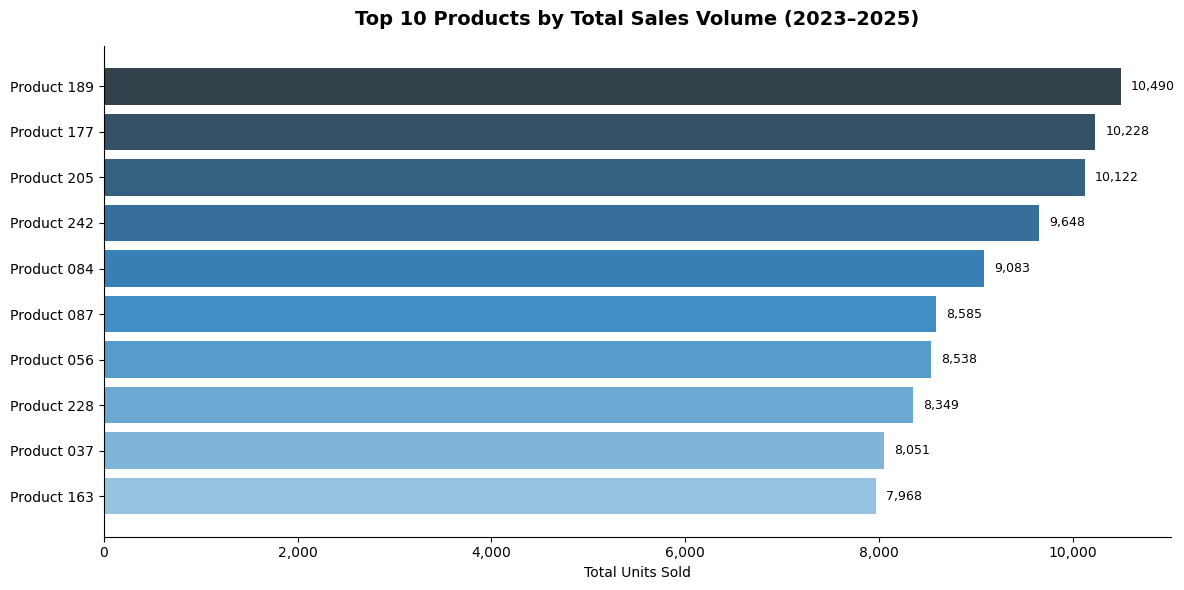

Chart saved: 02_top10_products_sales.png


In [7]:
# Top 10 products by total sales volume
top10_products = (sales_long.groupby('Product_name')['Value']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_products['Product_name'][::-1],
               top10_products['Value'][::-1],
               color=sns.color_palette('Blues_d', 10))

# Add value labels
for bar, val in zip(bars, top10_products['Value'][::-1]):
    ax.text(bar.get_width() + top10_products['Value'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 Products by Total Sales Volume (2023–2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Units Sold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('02_top10_products_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 02_top10_products_sales.png')

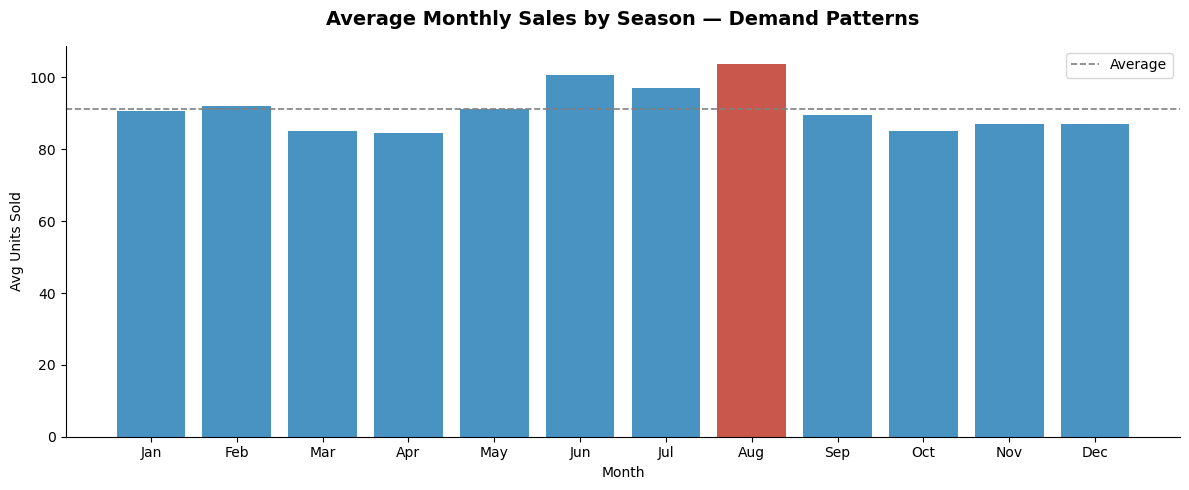

Chart saved: 03_seasonality.png


In [8]:
# Seasonality: Average sales by month number
sales_long['MonthNum'] = sales_long['Month'].dt.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

seasonality = (sales_long.groupby('MonthNum')['Value']
               .mean()
               .reset_index())
seasonality['MonthName'] = seasonality['MonthNum'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#c0392b' if v == seasonality['Value'].max()
          else '#2980b9' for v in seasonality['Value']]
ax.bar(seasonality['MonthName'], seasonality['Value'], color=colors, alpha=0.85)
ax.axhline(seasonality['Value'].mean(), color='gray',
           linestyle='--', linewidth=1.2, label='Average')

ax.set_title('Average Monthly Sales by Season — Demand Patterns',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Avg Units Sold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('03_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 03_seasonality.png')

## 4. Storage Cost Analysis

In [9]:
# Calculate estimated monthly storage cost per product
# Storage cost = avg monthly stock held × storage cost per unit per month

avg_stock = (stock_long.groupby(['ProductID','Product_name'])['Value']
             .mean()
             .reset_index()
             .rename(columns={'Value': 'Avg_monthly_stock'}))

cost_df = avg_stock.merge(params[['ProductID','Storage_cost_PLN_per_unit_month',
                                   'Shelf_life_months','Lead_time_months',
                                   'Safety_stock_months','Price_PLN_per_unit']],
                          on='ProductID', how='left')

cost_df['Monthly_storage_cost_PLN'] = (cost_df['Avg_monthly_stock'] *
                                        cost_df['Storage_cost_PLN_per_unit_month'])
cost_df['Annual_storage_cost_PLN']  = cost_df['Monthly_storage_cost_PLN'] * 12

# Total annual storage cost
total_annual = cost_df['Annual_storage_cost_PLN'].sum()
print(f'Total estimated annual storage cost: PLN {total_annual:,.0f}')
print(f' (~AUD {total_annual/2.5:,.0f} at approx exchange rate)')
print(f'\nTop 5 most expensive products to store:')
print(cost_df.nlargest(5, 'Annual_storage_cost_PLN')
      [['Product_name','Avg_monthly_stock','Monthly_storage_cost_PLN','Annual_storage_cost_PLN']])

Total estimated annual storage cost: PLN 737,282
 (~AUD 294,913 at approx exchange rate)

Top 5 most expensive products to store:
    Product_name  Avg_monthly_stock  Monthly_storage_cost_PLN  \
241  Product 242         949.305556               1310.041667   
188  Product 189        1033.527778               1126.545278   
55   Product 056         965.472222               1052.364722   
81   Product 082         696.500000                863.660000   
227  Product 228         908.666667                845.060000   

     Annual_storage_cost_PLN  
241             15720.500000  
188             13518.543333  
55              12628.376667  
81              10363.920000  
227             10140.720000  


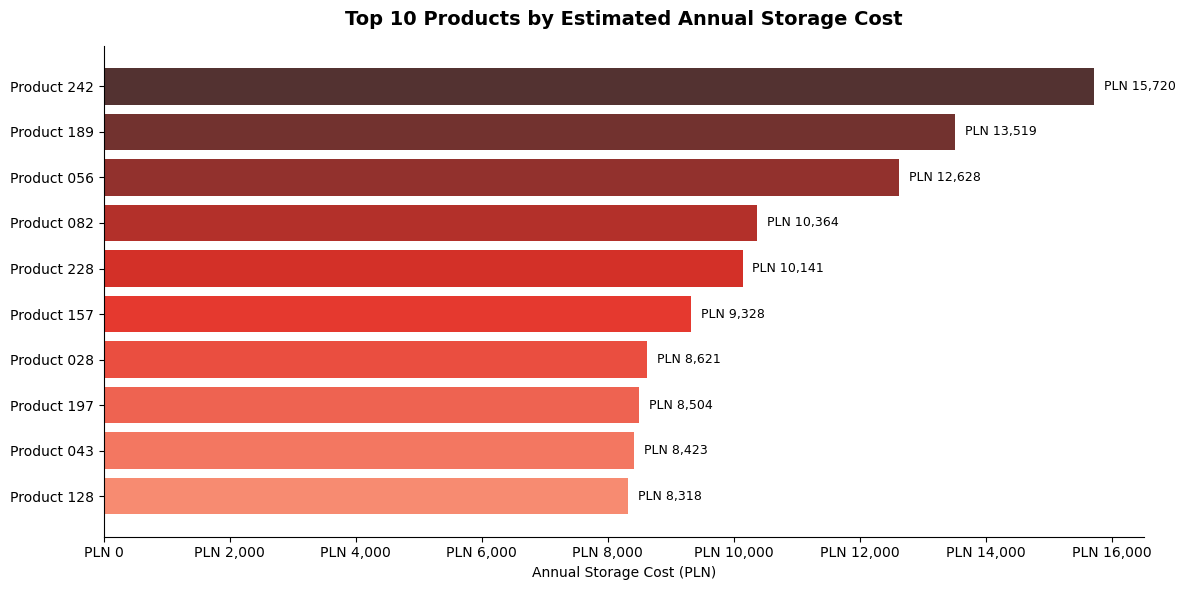

Chart saved: 04_top10_storage_cost.png


In [10]:
# Top 10 products by annual storage cost
top10_cost = cost_df.nlargest(10, 'Annual_storage_cost_PLN').copy()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_cost['Product_name'][::-1],
               top10_cost['Annual_storage_cost_PLN'][::-1],
               color=sns.color_palette('Reds_d', 10))

for bar, val in zip(bars, top10_cost['Annual_storage_cost_PLN'][::-1]):
    ax.text(bar.get_width() + top10_cost['Annual_storage_cost_PLN'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'PLN {val:,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 Products by Estimated Annual Storage Cost',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Annual Storage Cost (PLN)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PLN {x:,.0f}'))
plt.tight_layout()
plt.savefig('04_top10_storage_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 04_top10_storage_cost.png')

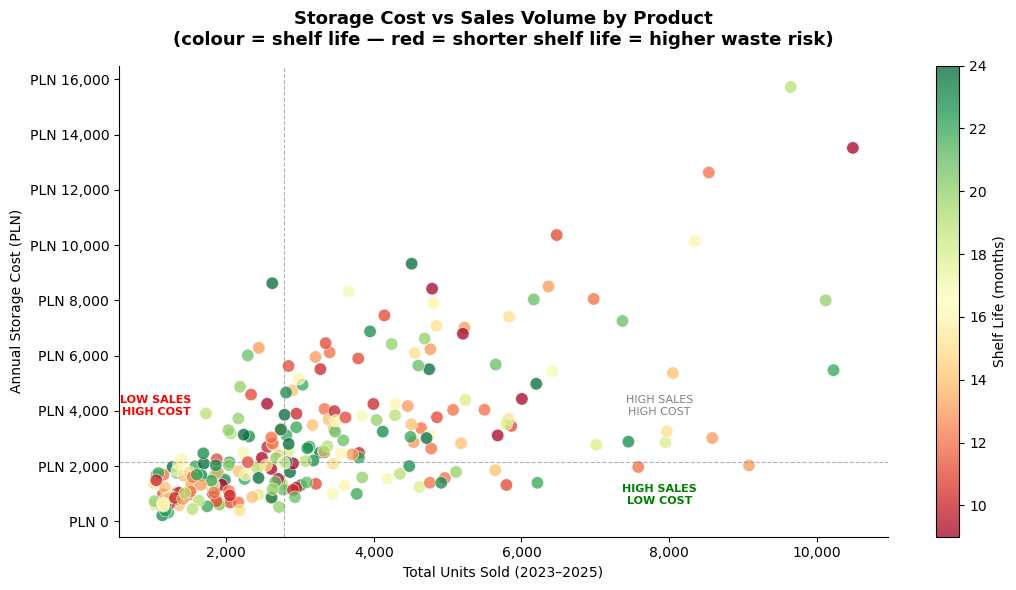

Chart saved: 05_cost_vs_sales_scatter.png


In [11]:
# Storage cost vs sales volume scatter
# Are high-cost products actually high sellers? Or are we paying to store slow movers?

total_sales_prod = (sales_long.groupby('ProductID')['Value']
                    .sum()
                    .reset_index()
                    .rename(columns={'Value':'Total_sales'}))

scatter_df = cost_df.merge(total_sales_prod, on='ProductID', how='left')

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(scatter_df['Total_sales'],
                scatter_df['Annual_storage_cost_PLN'],
                c=scatter_df['Shelf_life_months'],
                cmap='RdYlGn', s=80, alpha=0.75, edgecolors='white', linewidth=0.5)

plt.colorbar(sc, ax=ax, label='Shelf Life (months)')

# Quadrant lines
med_sales = scatter_df['Total_sales'].median()
med_cost  = scatter_df['Annual_storage_cost_PLN'].median()
ax.axvline(med_sales, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(med_cost,  color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Quadrant labels
ax.text(scatter_df['Total_sales'].max()*0.75, med_cost*1.8,
        'HIGH SALES\nHIGH COST', fontsize=8, color='gray', ha='center')
ax.text(scatter_df['Total_sales'].max()*0.1, med_cost*1.8,
        'LOW SALES\nHIGH COST', fontsize=8, color='red', ha='center', fontweight='bold')
ax.text(scatter_df['Total_sales'].max()*0.75, med_cost*0.3,
        'HIGH SALES\nLOW COST', fontsize=8, color='green', ha='center', fontweight='bold')

ax.set_title('Storage Cost vs Sales Volume by Product\n(colour = shelf life — red = shorter shelf life = higher waste risk)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total Units Sold (2023–2025)')
ax.set_ylabel('Annual Storage Cost (PLN)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PLN {x:,.0f}'))
plt.tight_layout()
plt.savefig('05_cost_vs_sales_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 05_cost_vs_sales_scatter.png')

## 5. Inventory Risk Analysis

In [12]:
# Stockout risk: months where stock < safety stock threshold
# Safety stock in months × avg monthly sales = minimum safe stock level

avg_monthly_sales = (sales_long.groupby('ProductID')['Value']
                     .mean()
                     .reset_index()
                     .rename(columns={'Value':'Avg_monthly_sales'}))

risk_df = cost_df.merge(avg_monthly_sales, on='ProductID', how='left')
risk_df['Min_safe_stock'] = (risk_df['Safety_stock_months'] *
                              risk_df['Avg_monthly_sales'])
risk_df['Stockout_risk'] = risk_df['Avg_monthly_stock'] < risk_df['Min_safe_stock']

at_risk = risk_df[risk_df['Stockout_risk']]
print(f'Products at stockout risk: {len(at_risk)} out of {len(risk_df)}')
print(f'That is {len(at_risk)/len(risk_df)*100:.1f}% of all products\n')

if len(at_risk) > 0:
    print('Top at-risk products (lowest stock vs safety threshold):')
    at_risk_display = at_risk.copy()
    at_risk_display['Stock_gap'] = (at_risk_display['Avg_monthly_stock'] -
                                     at_risk_display['Min_safe_stock'])
    print(at_risk_display.nsmallest(10, 'Stock_gap')
          [['Product_name','Avg_monthly_stock','Min_safe_stock','Stock_gap']])

Products at stockout risk: 0 out of 250
That is 0.0% of all products



### Finding: No Stockout Risk Detected
All 250 products maintain stock levels above their minimum safety threshold - indicating strong supply continuity across the portfolio. The primary inventory risk is therefore expiry/waste rather than stockout.

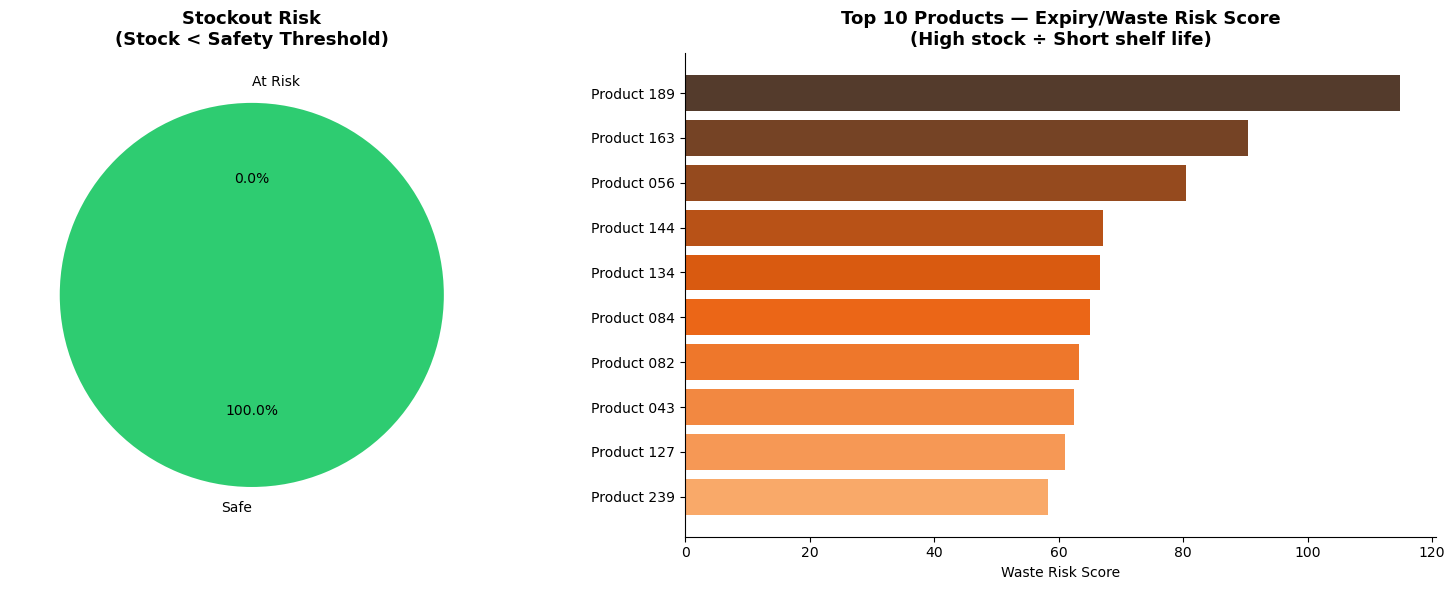

Chart saved: 06_inventory_risk.png


In [13]:
# Expiry/waste risk: short shelf life + high stock
risk_df['Waste_risk_score'] = (risk_df['Avg_monthly_stock'] /
                                risk_df['Shelf_life_months'].replace(0, np.nan))

top_waste_risk = risk_df.nlargest(10, 'Waste_risk_score').copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stockout risk
risk_counts = risk_df['Stockout_risk'].value_counts()
axes[0].pie([risk_counts.get(True, 0), risk_counts.get(False, 0)],
            labels=['At Risk', 'Safe'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Stockout Risk\n(Stock < Safety Threshold)',
                  fontsize=13, fontweight='bold')

# Waste risk
bars = axes[1].barh(top_waste_risk['Product_name'][::-1],
                    top_waste_risk['Waste_risk_score'][::-1],
                    color=sns.color_palette('Oranges_d', 10))
axes[1].set_title('Top 10 Products — Expiry/Waste Risk Score\n(High stock ÷ Short shelf life)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Waste Risk Score')

plt.tight_layout()
plt.savefig('06_inventory_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 06_inventory_risk.png')

## 6. Financial Plan vs Actual Sales Variance

In [14]:
# Actual sales totals per product per year
sales_long['Year'] = sales_long['Month'].dt.year

actual_by_year = (sales_long.groupby(['ProductID','Year'])['Value']
                  .sum()
                  .unstack(fill_value=0)
                  .reset_index())
actual_by_year.columns = ['ProductID'] + [f'Actual_{y}' for y in actual_by_year.columns[1:]]

# Merge with financial plan
var_df = fplan.merge(actual_by_year, on='ProductID', how='left')

# Calculate variances for each year present
for yr in [2023, 2024, 2025]:
    plan_col   = f'Plan_{yr}_units'
    actual_col = f'Actual_{yr}'
    if plan_col in var_df.columns and actual_col in var_df.columns:
        var_df[f'Var_{yr}_units'] = var_df[actual_col] - var_df[plan_col]
        var_df[f'Var_{yr}_pct']   = (var_df[f'Var_{yr}_units'] /
                                      var_df[plan_col].replace(0, np.nan) * 100).round(1)

print('Variance analysis complete')
print(f'Products analysed: {len(var_df)}')

# Summary
for yr in [2023, 2024]:
    if f'Var_{yr}_units' in var_df.columns:
        over  = (var_df[f'Var_{yr}_pct'] > 10).sum()
        under = (var_df[f'Var_{yr}_pct'] < -10).sum()
        print(f'\n{yr}: {over} products >10% above plan | {under} products >10% below plan')

Variance analysis complete
Products analysed: 250

2023: 95 products >10% above plan | 16 products >10% below plan

2024: 93 products >10% above plan | 21 products >10% below plan


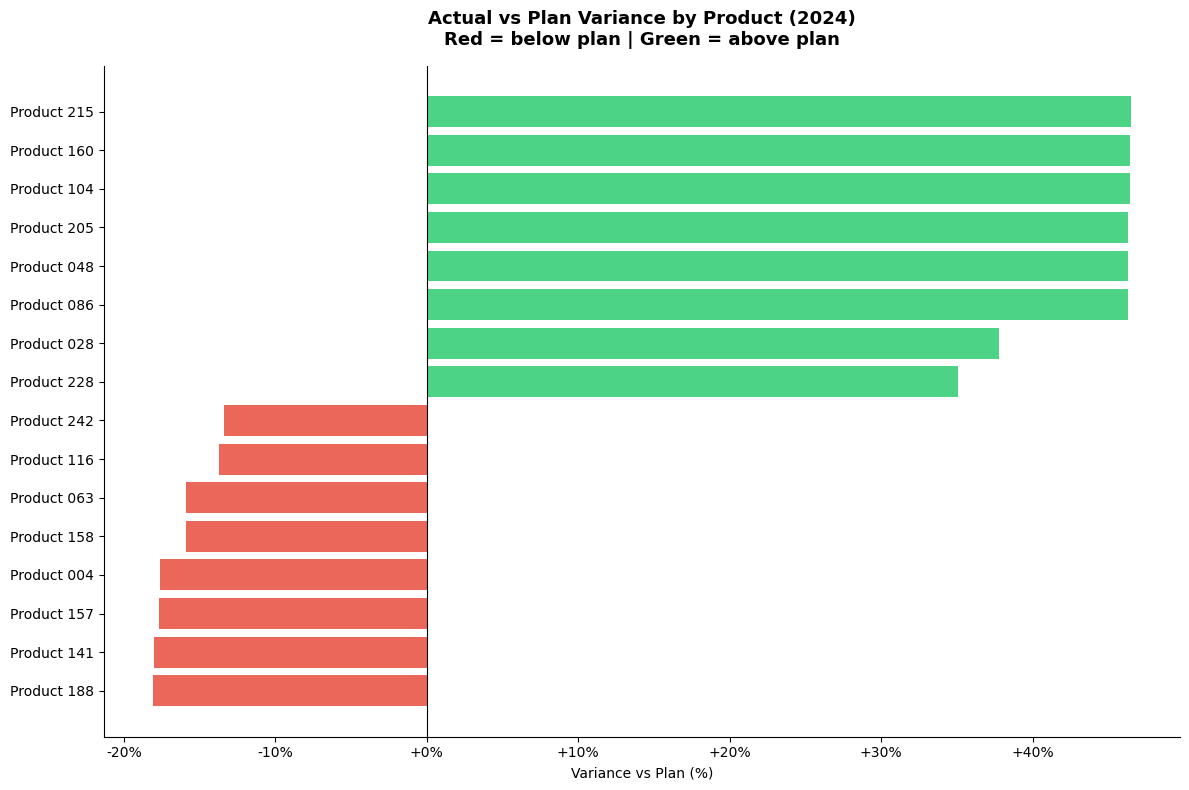

Chart saved: 07_plan_vs_actual_variance.png


In [15]:
# Variance chart: top over and under performers
yr = 2024  # focus on most recent complete year
var_col = f'Var_{yr}_pct'

if var_col in var_df.columns:
    var_plot = var_df[['Product_name', var_col]].dropna().copy()
    var_plot = var_plot.sort_values(var_col)

    # Top 8 over and under
    extremes = pd.concat([var_plot.head(8), var_plot.tail(8)])

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in extremes[var_col]]
    ax.barh(extremes['Product_name'], extremes[var_col], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)

    ax.set_title(f'Actual vs Plan Variance by Product ({yr})\n'
                 f'Red = below plan | Green = above plan',
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Variance vs Plan (%)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
    plt.tight_layout()
    plt.savefig('07_plan_vs_actual_variance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart saved: 07_plan_vs_actual_variance.png')

## 7. Key Findings & Business Recommendations

In [16]:
print('=' * 60)
print('KEY FINDINGS SUMMARY')
print('=' * 60)

print(f"""
 SALES OVERVIEW
  • Total products analysed : {sales_long['ProductID'].nunique()}
  • Analysis period         : Jan 2023 – Dec 2025 (36 months)
  • Total units sold (train) : {sales_long[sales_long['Year'].isin([2023,2024])]['Value'].sum():,.0f}

 STORAGE COSTS
  • Est. total annual storage cost : PLN {total_annual:,.0f}
  • Top cost product               : {cost_df.nlargest(1,'Annual_storage_cost_PLN')['Product_name'].values[0]}
  • Top 3 products account for     : {cost_df.nlargest(3,'Annual_storage_cost_PLN')['Annual_storage_cost_PLN'].sum()/total_annual*100:.1f}% of total storage cost

 INVENTORY RISK
  • Products at stockout risk : {len(at_risk)} ({len(at_risk)/len(risk_df)*100:.1f}%)
  • Products with expiry risk : {(risk_df['Waste_risk_score'] > risk_df['Waste_risk_score'].median()).sum()}
""")

print('=' * 60)
print('BUSINESS RECOMMENDATIONS')
print('=' * 60)
print("""
1. PRIORITISE EXPIRY WASTE REDUCTION — HIGHEST PRIORITY 
50% of products (125 out of 250) show elevated expiry risk, meaning stock is being held longer than shelf life safely 
allows. For hospital pharmaceuticals, expired product represents both financial waste and patient safety risk. Implementing 
demand-driven reorder quantities would directly reduce this exposure.

2. REVIEW STORAGE COST DISTRIBUTION
Annual storage costs of PLN 737,282 are spread relatively evenly across all 250 products (top 3 account for only 5.7%). 
This suggests a systemic over-stocking pattern rather than a few problem products — supporting a company-wide inventory 
policy review.

3. REPLACE MANUAL FORECASTING WITH DATA-DRIVEN PLANNING
Current manual financial planning shows significant variance against actual sales. Incorporating 36 months of historical 
sales trends and seasonality patterns into forecasting would improve planning accuracy and directly reduce both
over-stocking and expiry waste.

4. IMPLEMENT JUST-IN-TIME ORDERING FOR SHORT SHELF-LIFE PRODUCTS
Products with shelf life under 6 months should be prioritised for JIT ordering schedules to minimise the window between 
receipt and use, reducing expiry waste without compromising supply continuity.
""")

KEY FINDINGS SUMMARY

 SALES OVERVIEW
  • Total products analysed : 250
  • Analysis period         : Jan 2023 – Dec 2025 (36 months)
  • Total units sold (train) : 539,260

 STORAGE COSTS
  • Est. total annual storage cost : PLN 737,282
  • Top cost product               : Product 242
  • Top 3 products account for     : 5.7% of total storage cost

 INVENTORY RISK
  • Products at stockout risk : 0 (0.0%)
  • Products with expiry risk : 125

BUSINESS RECOMMENDATIONS

1. PRIORITISE EXPIRY WASTE REDUCTION — HIGHEST PRIORITY 
50% of products (125 out of 250) show elevated expiry risk, meaning stock is being held longer than shelf life safely 
allows.For hospital pharmaceuticals, expired product represents both financial waste and patient safety risk. Implementing 
demand-driven reorder quantities would directly reduce this exposure.

2. REVIEW STORAGE COST DISTRIBUTION
Annual storage costs of PLN 737,282 are spread relatively evenly across all 250 products (top 3 account for only 5.7%). 


---
## 8. Export Data for Power BI Dashboard

In [17]:
# Export clean tables for Power BI
# Power BI will connect to these CSV exports

# 1. Monthly sales (long format)
sales_export = sales_long[['ProductID','Product_name','Month','Value','Year']].copy()
sales_export.columns = ['ProductID','Product_name','Month','Units_sold','Year']
sales_export.to_csv('export_monthly_sales.csv', index=False)

# 2. Monthly stock levels
stock_export = stock_long[['ProductID','Product_name','Month','Value']].copy()
stock_export.columns = ['ProductID','Product_name','Month','Stock_level']
stock_export.to_csv('export_monthly_stock.csv', index=False)

# 3. Product cost & risk summary
cost_export = cost_df[['ProductID','Product_name','Avg_monthly_stock',
                        'Storage_cost_PLN_per_unit_month','Monthly_storage_cost_PLN',
                        'Annual_storage_cost_PLN','Shelf_life_months',
                        'Lead_time_months','Safety_stock_months','Price_PLN_per_unit']].copy()
cost_export.to_csv('export_product_cost_summary.csv', index=False)

# 4. Variance summary
var_cols = ['ProductID','Product_name'] + [c for c in var_df.columns
            if c.startswith('Plan_') or c.startswith('Actual_') or c.startswith('Var_')]
var_df[var_cols].to_csv('export_variance_summary.csv', index=False)

# 5. Risk summary
risk_export = risk_df[['ProductID','Product_name','Avg_monthly_stock',
                        'Min_safe_stock','Stockout_risk','Waste_risk_score']].copy()
risk_export.to_csv('export_risk_summary.csv', index=False)

print('All Power BI export files successfully saved')

All Power BI export files successfully saved
